# 01: Toy HMM — Forward Pass & Verification

## Goals
1. Define a 2-state Gaussian HMM with hand-set parameters (calm/crisis regimes)
2. Write a generative sampler that produces synthetic observation sequences and hidden states
3. Implement the forward pass (α recursion) from Bishop 13.36–13.37
4. Verify: normalized forward-pass state probabilities should roughly track the true hidden states

## Setup
- K = 2 states: calm (k=0), crisis (k=1)
- Parameters are hand-set, not learned
- All math follows Bishop PRML 13.2

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

In [7]:
pi = np.array([0.8, 0.2]) # (80% chance of starting in calm)
A = np.array([[0.95, 0.05], [0.1, 0.9]]) # (Calm remains 95% of the time, crisis does so 90%)
mu = np.array([0.05, -0.2]) # (Calm has a small positive mean, crisis has negative mean)
sigma_squared = np.array([1.0, 4.0]) # (Crisis has much higher variance)
latent_state = 0 # (0 indexing all states)

In [8]:
def sample_hmm(pi, A, mu, sigma_squared, N):
    states = np.zeros(N, dtype=int)
    observations = np.zeros(N)

    # Sample z_1 from pi
    states[0] = np.random.choice([0,1], p=pi)
    observations[0] = np.random.normal(loc=mu[states[0]], scale=np.sqrt(sigma_squared[states[0]]))

    for n in range (1, N):
        states[n] = np.random.choice([0,1], p=A[states[n-1]])
        observations[n] = np.random.normal(loc=mu[states[n]], scale=np.sqrt(sigma_squared[states[n]]))

    return states, observations

In [8]:
def sample_hmm(pi, A, mu, sigma_squared, N):
    states = np.zeros(N, dtype=int)
    observations = np.zeros(N)

    # Sample z_1 from pi
    states[0] = np.random.choice([0,1], p=pi)
    observations[0] = np.random.normal(loc=mu[states[0]], scale=np.sqrt(sigma_squared[states[0]]))

    for n in range (1, N):
        states[n] = np.random.choice([0,1], p=A[states[n-1]])
        observations[n] = np.random.normal(loc=mu[states[n]], scale=np.sqrt(sigma_squared[states[n]]))

    return states, observations

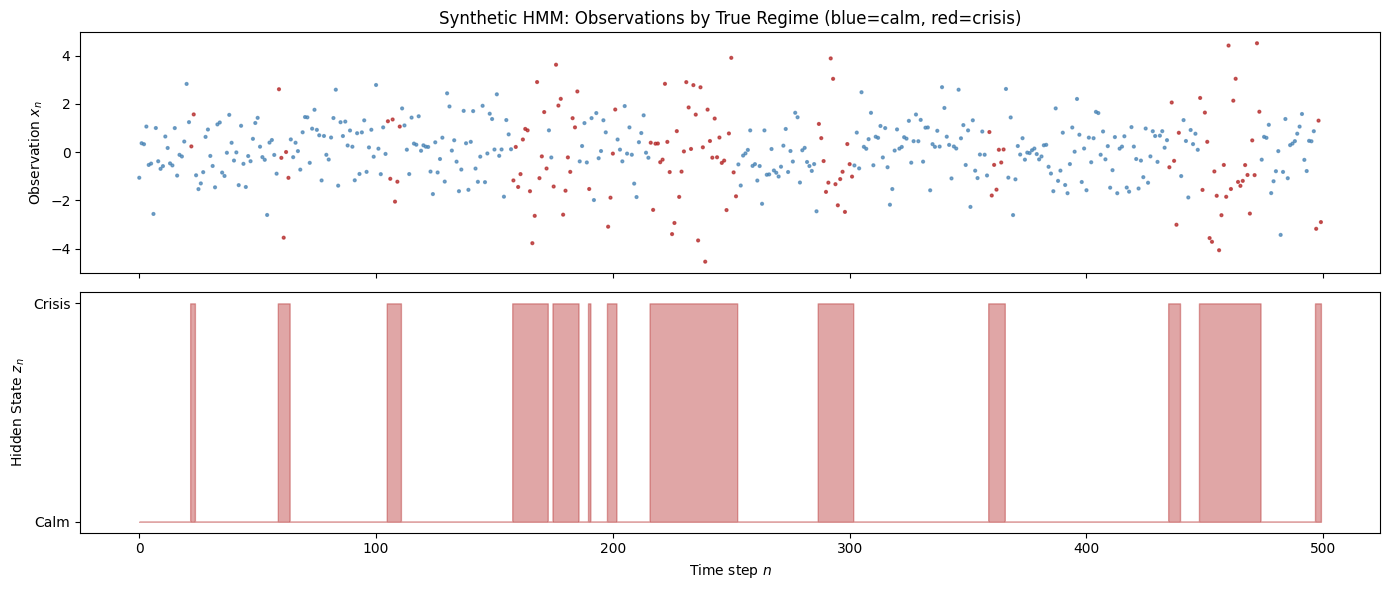

In [9]:
N = 500
states, observations = sample_hmm(pi, A, mu, sigma_squared, N)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Top: observations colored by true regime
colors = np.where(states == 0, 'steelblue', 'firebrick')
ax1.scatter(range(N), observations, c=colors, s=4, alpha=0.7)
ax1.set_ylabel('Observation $x_n$')
ax1.set_title('Synthetic HMM: Observations by True Regime (blue=calm, red=crisis)')

# Bottom: true hidden state
ax2.fill_between(range(N), states, alpha=0.4, color='firebrick', step='mid')
ax2.set_ylabel('Hidden State $z_n$')
ax2.set_xlabel('Time step $n$')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Calm', 'Crisis'])

plt.tight_layout()
plt.show()

In [17]:
# Forward pass function for alpha returning array of shape (N, 2)
def forward_pass(observations, pi, A, mu, sigma_squared):
    N = len(observations)
    alpha = np.zeros((N, 2))
    
    # alpha initialization:
    # initial state probability * emission density
    for k in range(2):
        alpha[0,k] = pi[k] * norm.pdf(observations[0], loc=mu[k], scale=np.sqrt(sigma_squared[k]))
    # Need to normalize here since values underflow
    alpha[0, :] /= alpha[0, :].sum()
        
    for n in range(1, N):
        for k in range(2):
            # emission probability of x_n under state k, multiplied by 
            # the sum over all previous states j
            alpha[n,k] = norm.pdf(observations[n], loc=mu[k], scale=np.sqrt(sigma_squared[k]))
            previous_states = 0
            for j in range(2):
                previous_states += alpha[n-1, j] * A[j, k]
            alpha[n, k] *= previous_states
        # Underflow protection
        alpha[n, :] /= alpha[n, :].sum()

    return alpha

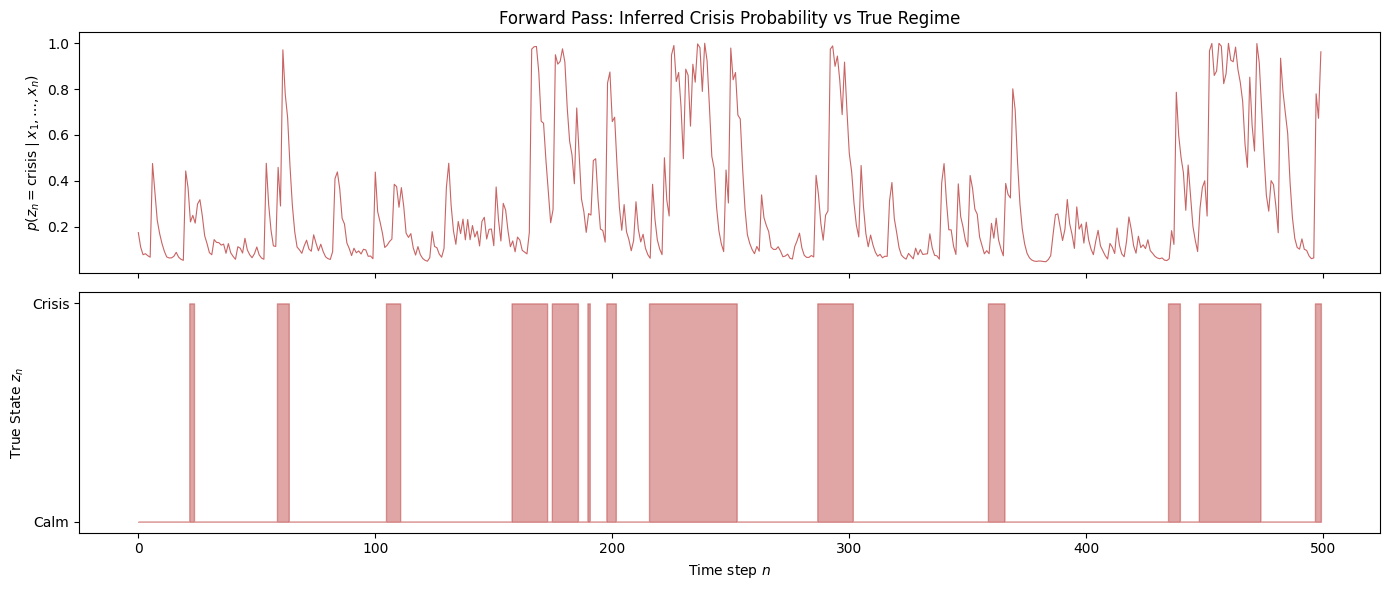

In [18]:
alpha = forward_pass(observations, pi, A, mu, sigma_squared)

# Plot inferred crisis probability vs true state
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(alpha[:, 1], color='firebrick', alpha=0.7, linewidth=0.8)
ax1.set_ylabel('$p(z_n = \\mathrm{crisis} \\mid x_1, \\ldots, x_n)$')
ax1.set_title('Forward Pass: Inferred Crisis Probability vs True Regime')

ax2.fill_between(range(N), states, alpha=0.4, color='firebrick', step='mid')
ax2.set_ylabel('True State $z_n$')
ax2.set_xlabel('Time step $n$')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Calm', 'Crisis'])

plt.tight_layout()
plt.show()